Dataset Overview
577 rows (samples)
18 columns total
Target variable: score (CER - Character Error Rate)
🎯 Target Variable
score: CER score ranging from 0.2778 to 1.0000
Lower values = better OCR accuracy
Mean: 0.9192 (generally good OCR performance)
📊 Categorical Features (9 total)
1. rotation (2 categories)
upright - Normal orientation
clockwise - Rotated image
2. clarity (3 categories)
clear - Sharp, focused image
slightly_blur - Minor blur
very_blur - Heavily blurred
3. handwriting (2 categories)
good - High quality handwriting
okay - Acceptable handwriting
4. writing_style (3 categories)
neat_and_tidy - Very organized writing
okay - Acceptable style
messy - Disorganized writing
5. lighting (3 categories)
strong_contrast_shadows - High contrast with shadows
consistent - Even lighting
glare_on_text - Reflective glare affecting text
6. resolution (2 categories)
high - High pixel density
medium - Standard resolution
7. paper_condition (2 categories)
clean - Pristine paper
folded - Creased/folded paper
8. text_alignment (2 categories)
well_aligned - Properly oriented text
slightly_misaligned - Minor alignment issues
9. Strikethrough (2 categories)
absent - No crossed-out text
present - Contains strikethrough text

## train a model catboost

In [4]:
pip install catboost pandas numpy scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/all_subjects_car.csv')

# Display the first few rows to inspect the data
print(df.head())


                                          gemini_ocr  \
0  6. in △opr,ro^2 = pr^2 + op^2ro^2 = 12^2 + 5^2...   
1  28. p(2,5), q(x,y), r(8,3)m₁:m₂1:2q = (x₁m₂+x₂...   
2  8.light reactioni) it takes place in the grana...   
3  6 -> the ratio of speed of light in vacume and...   
4  16. givenδabe ≅ δacd.<diagram_3>to prove thatδ...   

                                        Ground_Truth     score  length  \
0  6.pr = 12 cm, op = 5cm and oq = 4cmqp = oq + o...  0.277778     230   
1  28.(ii) pr = √(8-2)² + (3-5)²= √6² + 2²= √36 +...  0.344262     118   
2  8.| Light Reaction | Dark reaction || :--- | :...  0.410359     315   
3  6 -> The ratio of speed of light in vacume and...  0.452000     311   
4  16: givenδabe ≅ δacd.to prove thatδade ~ δabc<...  0.459075     188   

   question_number page_number                           pdf_name  \
0              6.0         2,3  10_100210404319737581171703337845   
1             28.0    18,19,20   02_10021028581065351171694350945   
2          

## Data Preprocessing

In [6]:
#3.1 Check for Missing Values
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/all_subjects_car.csv')

# Check for missing values
print(df.isnull().sum())



gemini_ocr           0
Ground_Truth         0
score                0
length               0
question_number      0
page_number          0
pdf_name             0
text_present_only    6
subject              0
rotation             0
clarity              0
handwriting          0
writing_style        0
lighting             0
resolution           0
paper_condition      0
text_alignment       0
Strikethrough        0
dtype: int64


In [7]:
# Load the dataset
df = pd.read_csv('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/all_subjects_car.csv')

# Display column names to check the correct name of the CER score column
print(df.columns)


Index(['gemini_ocr', 'Ground_Truth', 'score', 'length', 'question_number',
       'page_number', 'pdf_name', 'text_present_only', 'subject', 'rotation',
       'clarity', 'handwriting', 'writing_style', 'lighting', 'resolution',
       'paper_condition', 'text_alignment', 'Strikethrough'],
      dtype='object')


In [8]:
#3.2 Identify Categorical Features
# List of categorical features
categorical_features = ['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting', 
                        'resolution', 'paper_condition', 'text_alignment', 'Strikethrough']

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
df = pd.read_csv('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/all_subjects_car.csv')

print(f"Total rows in original dataset: {len(df)}")

# Features (rotation, clarity, etc.) and target (CER score)
categorical_features = ['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting', 
                        'resolution', 'paper_condition', 'text_alignment', 'Strikethrough']
target = 'score'  # CER score is in the 'score' column

# Define features (X) and target variable (y)
X = df[categorical_features]
y = df[target]

# Split the data into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData split information:")
print(f"Training set rows: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set rows: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Split ratio - Train:Val = {len(X_train)}:{len(X_val)} = {len(X_train)/len(X_val):.1f}:1")

# Combine features and target for training and validation sets (includes all columns)
train_data = pd.concat([X_train, y_train], axis=1)  # Merge features and target for training set
val_data = pd.concat([X_val, y_val], axis=1)  # Merge features and target for validation set

# Now, we want to add the other columns (e.g., 'pdf_name', 'page_number') from the original dataframe
# Add the extra columns (pdf_name, page_number, etc.) to the training and validation sets
train_data = pd.concat([train_data, df.loc[X_train.index, ['pdf_name', 'page_number', 'gemini_ocr', 'Ground_Truth', 'length', 'question_number', 'text_present_only', 'subject']]], axis=1)
val_data = pd.concat([val_data, df.loc[X_val.index, ['pdf_name', 'page_number', 'gemini_ocr', 'Ground_Truth', 'length', 'question_number', 'text_present_only', 'subject']]], axis=1)

print(f"\nFinal dataset sizes after adding all columns:")
print(f"Training data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")

# Save the training and validation sets to CSV (now including all columns)
train_data.to_csv('train_data_with_all_columns.csv', index=False)
val_data.to_csv('val_data_with_all_columns.csv', index=False)

print("\nTraining and validation sets with all columns have been saved to CSV.")

Total rows in original dataset: 577

Data split information:
Training set rows: 461 (79.9%)
Validation set rows: 116 (20.1%)
Split ratio - Train:Val = 461:116 = 4.0:1

Final dataset sizes after adding all columns:
Training data shape: (461, 18)
Validation data shape: (116, 18)

Training and validation sets with all columns have been saved to CSV.


In [10]:
# Load your dataset
df = pd.read_csv('train_data_with_all_columns.csv')

# Print the list of column names to check all available features
print("Column Names:", df.columns)

# Check the total number of features
print("Total Number of Features:", len(df.columns))


Column Names: Index(['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting',
       'resolution', 'paper_condition', 'text_alignment', 'Strikethrough',
       'score', 'pdf_name', 'page_number', 'gemini_ocr', 'Ground_Truth',
       'length', 'question_number', 'text_present_only', 'subject'],
      dtype='object')
Total Number of Features: 18


## Step 4: Train the CatBoost Model


In [17]:
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error

# Load the training and validation data with all columns
train_data = pd.read_csv('train_data_with_all_columns.csv')
val_data = pd.read_csv('val_data_with_all_columns.csv')

# Display the first few rows to verify
print(train_data.head())


  rotation        clarity handwriting  writing_style                 lighting  \
0  upright  slightly_blur        good  neat_and_tidy  strong_contrast_shadows   
1  upright          clear        good  neat_and_tidy  strong_contrast_shadows   
2  upright          clear        good  neat_and_tidy  strong_contrast_shadows   
3  upright          clear        good  neat_and_tidy               consistent   
4  upright          clear        okay           okay  strong_contrast_shadows   

  resolution paper_condition text_alignment Strikethrough     score  \
0     medium           clean   well_aligned       present  0.777778   
1       high           clean   well_aligned       present  1.000000   
2     medium           clean   well_aligned       present  0.769784   
3       high           clean   well_aligned       present  1.000000   
4       high           clean   well_aligned       present  0.762500   

                           pdf_name page_number  \
0  10_10021138351083421111694954514

In [18]:
# Check the data types of the features
print(train_data[categorical_features].dtypes)


rotation           object
clarity            object
handwriting        object
writing_style      object
lighting           object
resolution         object
paper_condition    object
text_alignment     object
Strikethrough      object
dtype: object


0:	learn: 0.1180293	test: 0.1211895	best: 0.1211895 (0)	total: 59.1ms	remaining: 59s
100:	learn: 0.1082928	test: 0.1207701	best: 0.1204718 (43)	total: 498ms	remaining: 4.43s
200:	learn: 0.0958027	test: 0.1224326	best: 0.1204718 (43)	total: 2.78s	remaining: 11.1s
300:	learn: 0.0856624	test: 0.1257185	best: 0.1204718 (43)	total: 6.67s	remaining: 15.5s
400:	learn: 0.0783472	test: 0.1270931	best: 0.1204718 (43)	total: 10.6s	remaining: 15.8s
500:	learn: 0.0737235	test: 0.1284618	best: 0.1204718 (43)	total: 14.5s	remaining: 14.4s
600:	learn: 0.0696212	test: 0.1295947	best: 0.1204718 (43)	total: 18.9s	remaining: 12.6s
700:	learn: 0.0669109	test: 0.1301000	best: 0.1204718 (43)	total: 23s	remaining: 9.8s
800:	learn: 0.0647228	test: 0.1302835	best: 0.1204718 (43)	total: 26.9s	remaining: 6.68s
900:	learn: 0.0626940	test: 0.1304403	best: 0.1204718 (43)	total: 30.9s	remaining: 3.39s
999:	learn: 0.0601569	test: 0.1306159	best: 0.1204718 (43)	total: 35.4s	remaining: 0us

bestTest = 0.1204717723
bestI

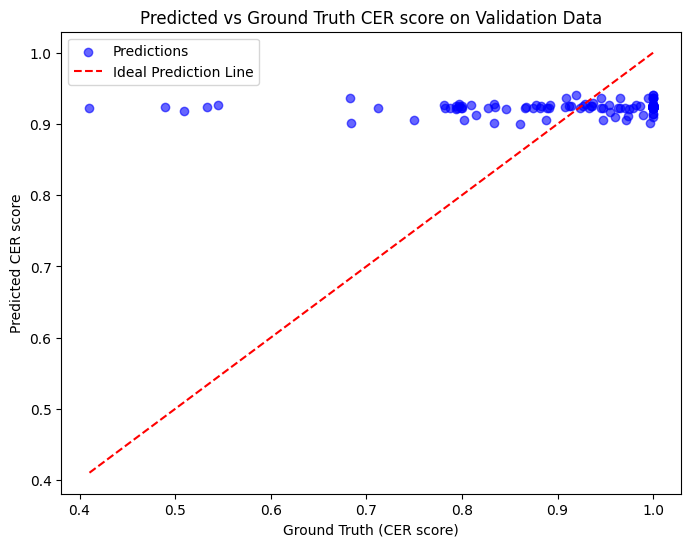

In [4]:
from catboost import CatBoostRegressor, Pool
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define categorical features
categorical_features = ['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting', 
                        'resolution', 'paper_condition', 'text_alignment', 'Strikethrough']

# Load the training and validation data
train_data = pd.read_csv('train_data_with_all_columns.csv')
val_data = pd.read_csv('val_data_with_all_columns.csv')

# Convert the categorical features to category dtype
for feature in categorical_features:
    train_data[feature] = train_data[feature].astype('category')
    val_data[feature] = val_data[feature].astype('category')

# Define target variable
target = 'score'  # CER score column

# Split the data into features and target
X_train = train_data[categorical_features]
y_train = train_data[target]
X_val = val_data[categorical_features]
y_val = val_data[target]

# Create CatBoost Pool objects for training and validation (CatBoost handles categorical features automatically)
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features) # Pool means the data to train the model with the categorical features 
val_pool = Pool(data=X_val, label=y_val, cat_features=categorical_features) # Pool means the data to validate the model with the categorical features

# Initialize CatBoost Regressor
model = CatBoostRegressor(iterations=1000,  # Enough rounds to learn patterns means the number of trees to grow
                          learning_rate=0.05, # Learning rate means the step size of the gradient descent
                          depth=16,  #Deeper trees might be better for complex relationships means more depth means more trees
                          loss_function='RMSE', # Loss function means the function to minimize means the error between the predicted and actual values
                          random_seed=42, # Random seed means the same random number will be generated every time
                          min_data_in_leaf=10, # Leaf size means the minimum number of samples required to be a leaf node
                          verbose=100) # Verbose to see progress means the number of iterations to print the progress

# Train the model
model.fit(train_pool, eval_set=val_pool) # Train the model with the training data and validate the model with the validation data

# Make predictions on the validation set
y_val_pred = model.predict(X_val) # Make predictions on the validation set

# Calculate RMSE on the validation set
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred)) # Calculate the RMSE on the validation set
print(f"Root Mean Squared Error (RMSE) on Validation Data: {rmse_val}")

# Plot predicted values vs ground truth for the validation set
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred, color='blue', alpha=0.6, label='Predictions')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--', label='Ideal Prediction Line')
plt.xlabel('Ground Truth (CER score)')
plt.ylabel('Predicted CER score')
plt.title('Predicted vs Ground Truth CER score on Validation Data')
plt.legend()
plt.show()


# Training:   0.11499 RMSE (12.51% error)
# Validation: 0.11976 RMSE (13.03% error)

## sanity check for ground truth and weight

RMSE on Training Data: 0.1160772556415631
✅ CSV saved as: training_predictions_with_ground_truth.csv
📊 Dataset info:
   • Total rows: 461
   • Total columns: 22
   • Mean absolute error: 0.085942
   • Max error: 0.659305
   • Min error: 0.001288

📋 Preview of predictions vs ground truth:
   predicted_score  ground_truth  prediction_error  error_percentage
0         0.925099      0.777778          0.147321         18.941307
1         0.922005      1.000000          0.077995          7.799484
2         0.921611      0.769784          0.151827         19.723268
3         0.926978      1.000000          0.073022          7.302185
4         0.905614      0.762500          0.143114         18.769085
5         0.905614      0.580000          0.325614         56.140391
6         0.921611      0.861789          0.059822          6.941627
7         0.922005      1.000000          0.077995          7.799484
8         0.925215      0.947059          0.021844          2.306527
9         0.898112   

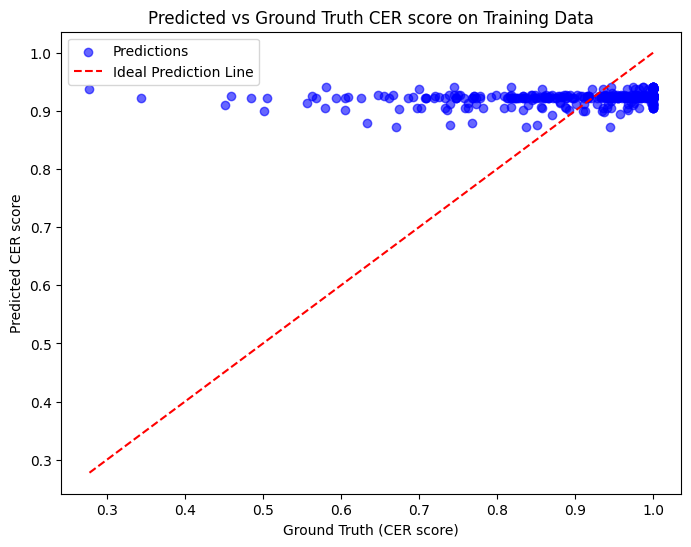


🎯 CSV file 'training_predictions_with_ground_truth.csv' contains:
   • predicted_score: Model predictions
   • ground_truth: Actual CER scores
   • score: Same as ground_truth (original column)
   • prediction_error: |predicted - actual|
   • error_percentage: (error/actual) * 100
   • All original data columns


In [21]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Calculate RMSE on the training data
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"RMSE on Training Data: {rmse_train}")

# Create a DataFrame with all training data + predictions
train_with_predictions = train_data.copy()
train_with_predictions['predicted_score'] = y_train_pred
train_with_predictions['ground_truth'] = y_train
train_with_predictions['prediction_error'] = abs(y_train - y_train_pred)
train_with_predictions['error_percentage'] = (abs(y_train - y_train_pred) / y_train) * 100

# Reorder columns to show predictions and ground truth first
important_cols = ['predicted_score', 'ground_truth', 'score', 'prediction_error', 'error_percentage']
other_cols = [col for col in train_with_predictions.columns if col not in important_cols]
column_order = important_cols + other_cols
train_with_predictions = train_with_predictions[column_order]

# Save to CSV
csv_filename = 'training_predictions_with_ground_truth.csv'
train_with_predictions.to_csv(csv_filename, index=False)

print(f"✅ CSV saved as: {csv_filename}")
print(f"📊 Dataset info:")
print(f"   • Total rows: {len(train_with_predictions)}")
print(f"   • Total columns: {len(train_with_predictions.columns)}")
print(f"   • Mean absolute error: {train_with_predictions['prediction_error'].mean():.6f}")
print(f"   • Max error: {train_with_predictions['prediction_error'].max():.6f}")
print(f"   • Min error: {train_with_predictions['prediction_error'].min():.6f}")

# Show preview of the predictions
print(f"\n📋 Preview of predictions vs ground truth:")
preview_cols = ['predicted_score', 'ground_truth', 'prediction_error', 'error_percentage']
print(train_with_predictions[preview_cols].head(10))

# Show statistics
print(f"\n📈 Prediction Statistics:")
print(f"   • Mean predicted score: {train_with_predictions['predicted_score'].mean():.4f}")
print(f"   • Mean ground truth: {train_with_predictions['ground_truth'].mean():.4f}")
print(f"   • Prediction std: {train_with_predictions['predicted_score'].std():.4f}")
print(f"   • Ground truth std: {train_with_predictions['ground_truth'].std():.4f}")

# Plot predicted values vs ground truth
plt.figure(figsize=(8, 6))

# Scatter plot of predicted vs actual values
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.6, label='Predictions')

# Plot the ideal line (y = x)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Ideal Prediction Line')

# Add labels and title
plt.xlabel('Ground Truth (CER score)')
plt.ylabel('Predicted CER score')
plt.title('Predicted vs Ground Truth CER score on Training Data')

# Show the legend
plt.legend()

# Display the plot
plt.show()

print(f"\n🎯 CSV file '{csv_filename}' contains:")
print("   • predicted_score: Model predictions")
print("   • ground_truth: Actual CER scores")  
print("   • score: Same as ground_truth (original column)")
print("   • prediction_error: |predicted - actual|")
print("   • error_percentage: (error/actual) * 100")
print("   • All original data columns")

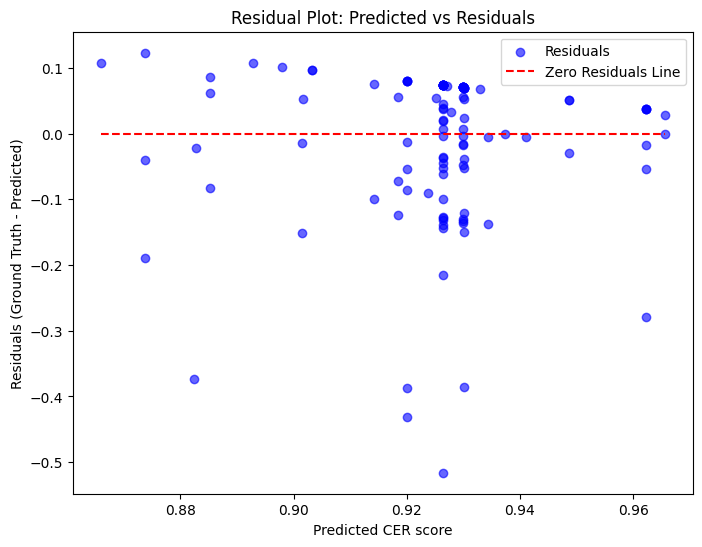

In [15]:
# Calculate residuals (errors between prediction and actual values)
residuals = y_val - y_val_pred

# Plot residuals
plt.figure(figsize=(8,6))
plt.scatter(y_val_pred, residuals, color='blue', alpha=0.6, label='Residuals')
plt.hlines(y=0, xmin=min(y_val_pred), xmax=max(y_val_pred), color='red', linestyle='--', label='Zero Residuals Line')
plt.xlabel('Predicted CER score')
plt.ylabel('Residuals (Ground Truth - Predicted)')
plt.title('Residual Plot: Predicted vs Residuals')
plt.legend()
plt.show()


In [16]:
# Load your dataset
df = pd.read_csv('train_data_with_all_columns.csv')

# Print the list of column names to check all available features
print("Column Names:", df.columns)

# Check the total number of features
print("Total Number of Features:", len(df.columns))


Column Names: Index(['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting',
       'resolution', 'paper_condition', 'text_alignment', 'Strikethrough',
       'score', 'pdf_name', 'page_number', 'gemini_ocr', 'Ground_Truth',
       'length', 'question_number', 'text_present_only', 'subject'],
      dtype='object')
Total Number of Features: 18


In [17]:
# Check the range of predicted values on the validation set
min_pred = min(y_val_pred)
max_pred = max(y_val_pred)
print(f"Min predicted CER score: {min_pred}")
print(f"Max predicted CER score: {max_pred}")


Min predicted CER score: 0.8659877193318205
Max predicted CER score: 0.9655824770154038


In [18]:
# Check how many predicted CER scores are greater than 1
count_greater_than_1 = np.sum(y_val_pred > 1.0)

# Print the count of predictions greater than 1
print(f"Number of predicted CER scores greater than 1: {count_greater_than_1}")


Number of predicted CER scores greater than 1: 0


In [19]:
# Display feature importance
importances = model.get_feature_importance()
for feature, importance in zip(categorical_features, importances):
    print(f"Feature: {feature}, Importance: {importance}")


Feature: rotation, Importance: 0.0
Feature: clarity, Importance: 24.403703573985954
Feature: handwriting, Importance: 3.996486301982377
Feature: writing_style, Importance: 20.212979148135318
Feature: lighting, Importance: 30.110835065725738
Feature: resolution, Importance: 5.098053938832708
Feature: paper_condition, Importance: 0.5217010025533478
Feature: text_alignment, Importance: 1.9550785574821188
Feature: Strikethrough, Importance: 13.701162411302414


In [20]:
# Make predictions on the training set (same as validation)
y_train_pred = model.predict(X_train)

# Calculate RMSE on the training data
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Root Mean Squared Error (RMSE) on Training Data: {rmse_train}")


Root Mean Squared Error (RMSE) on Training Data: 0.11498711984009842


RMSE on Training Data: 0.11498711984009842


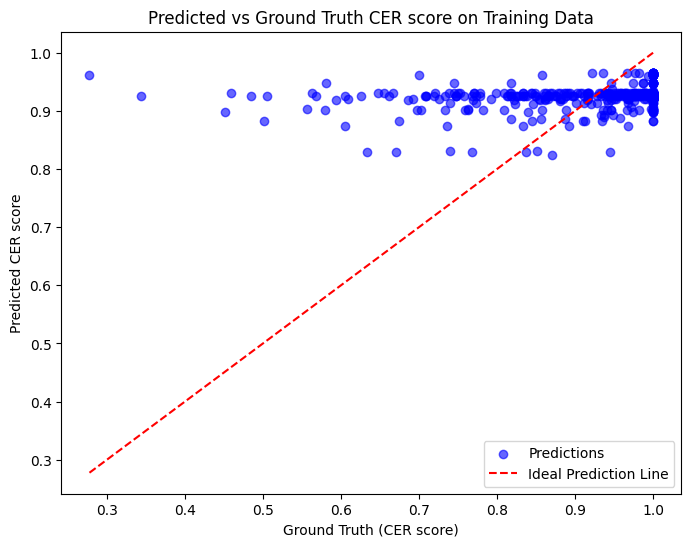

/var/folders/62/cwfgmpjx2rq78q__0nz165zh0000gp/T/ipykernel_76836/554498009.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


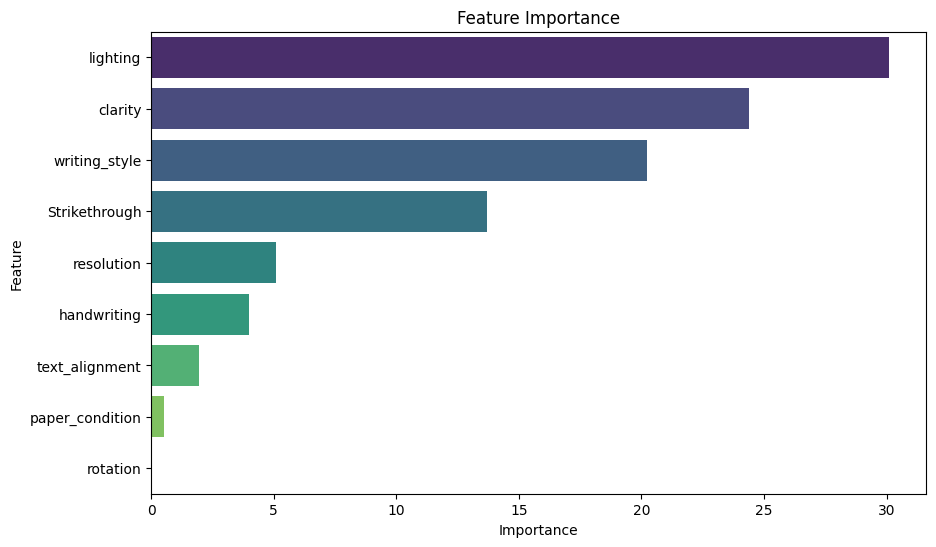

In [23]:
import seaborn as sns

# Create a DataFrame for the feature importance
feature_importance_df = pd.DataFrame({
    'Feature': categorical_features,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Add labels and title
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

# Display the plot
plt.show()


## check of model weights on validaiton set 

In [24]:
# Load your dataset
df = pd.read_csv('train_data_with_all_columns.csv')

# Print the list of column names to check all available features
print("Column Names:", df.columns)

# Check the total number of features
print("Total Number of Features:", len(df.columns))


Column Names: Index(['rotation', 'clarity', 'handwriting', 'writing_style', 'lighting',
       'resolution', 'paper_condition', 'text_alignment', 'Strikethrough',
       'score', 'pdf_name', 'page_number', 'gemini_ocr', 'Ground_Truth',
       'length', 'question_number', 'text_present_only', 'subject'],
      dtype='object')
Total Number of Features: 18


In [25]:
# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Calculate Root Mean Squared Error (RMSE) on the validation data
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Root Mean Squared Error (RMSE) on Validation Data: {rmse_val}")


Root Mean Squared Error (RMSE) on Validation Data: 0.11976370589623002


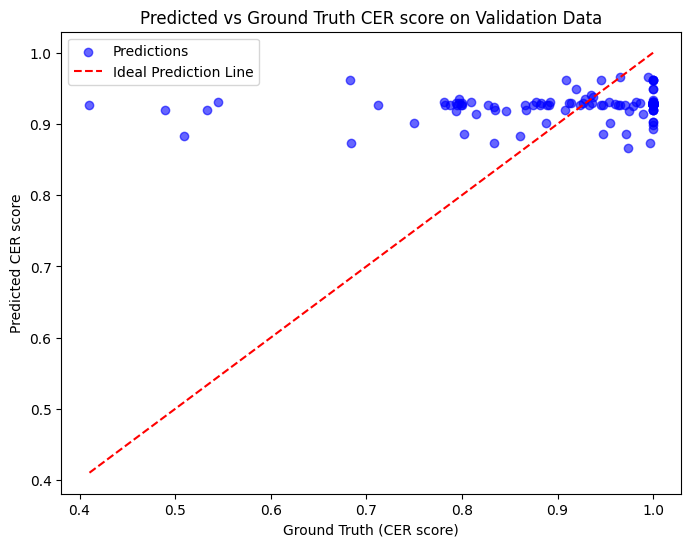

In [26]:
# Plot predicted values vs ground truth for the validation set
plt.figure(figsize=(8, 6))

# Scatter plot of predicted vs actual values for validation data
plt.scatter(y_val, y_val_pred, color='blue', alpha=0.6, label='Predictions')

# Plot the ideal line (y = x)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--', label='Ideal Prediction Line')

# Add labels and title
plt.xlabel('Ground Truth (CER score)')
plt.ylabel('Predicted CER score')
plt.title('Predicted vs Ground Truth CER score on Validation Data')

# Show the legend
plt.legend()

# Display the plot
plt.show()


In [27]:
import pandas as pd
import numpy as np

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Get the feature importance
importances = model.get_feature_importance()

# Create a DataFrame with the actual, predicted, and feature importance values
results_df = pd.DataFrame({
    'Ground_Truth_CER': y_val,
    'Predicted_CER': y_val_pred,
    'Rotation_Importance': [importances[0]] * len(y_val),
    'Clarity_Importance': [importances[1]] * len(y_val),
    'Handwriting_Importance': [importances[2]] * len(y_val),
    'Writing_Style_Importance': [importances[3]] * len(y_val),
    'Lighting_Importance': [importances[4]] * len(y_val),
    'Resolution_Importance': [importances[5]] * len(y_val),
    'Paper_Condition_Importance': [importances[6]] * len(y_val),
    'Text_Alignment_Importance': [importances[7]] * len(y_val),
    'Strikethrough_Importance': [importances[8]] * len(y_val)
})

# Save the DataFrame to CSV
results_df.to_csv('model_predictions_with_weights.csv', index=False)

print("CSV file with model predictions and feature importance has been saved.")


CSV file with model predictions and feature importance has been saved.
